Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split,RandomizedSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report 
from sklearn.metrics import precision_score,recall_score,f1_score,roc_auc_score


from xgboost import XGBClassifier

import joblib


Load Dataset

In [2]:
import sklearn
import xgboost
import joblib

print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("joblib:", joblib.__version__)

sklearn: 1.5.1
xgboost: 3.4.0
joblib: 1.4.2


In [3]:
df=pd.read_csv("Telco-Customer-Churn (4).csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [49]:
import sklearn
print(sklearn.__version__)



1.5.1


In [4]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


EDA (Exploratory Data Analysis)

In [5]:
df.shape

(7043, 21)

In [6]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.columns.tolist()


['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [9]:
(df==" ").sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Convert TotalCharges to Numeric

In [10]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [11]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

**Churn Distribution**

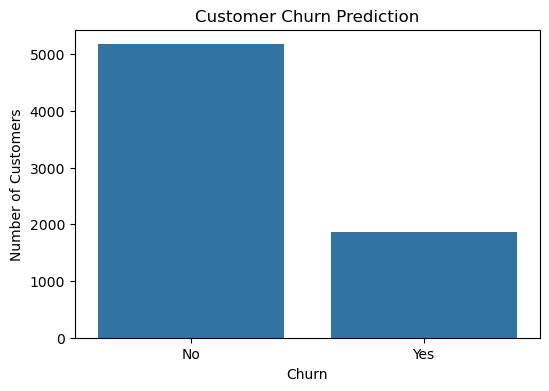

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn",
    data=df
)
plt.title("Customer Churn Prediction")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [14]:
# Churn Percentage 
churn_percentage=df["Churn"].value_counts(normalize=True)*100
print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


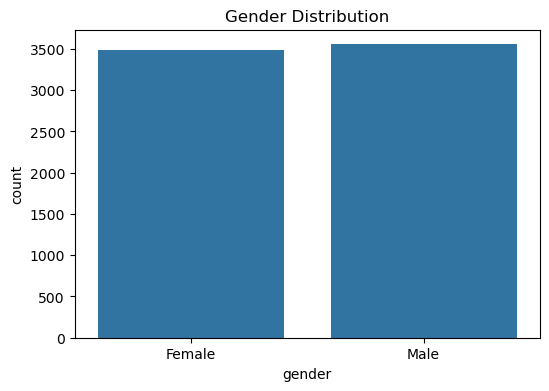

In [15]:
# Gender Distribution

plt.figure(figsize=(6,4))


sns.countplot(
    x="gender",
    data=df
)
plt.title("Gender Distribution")

plt.show()

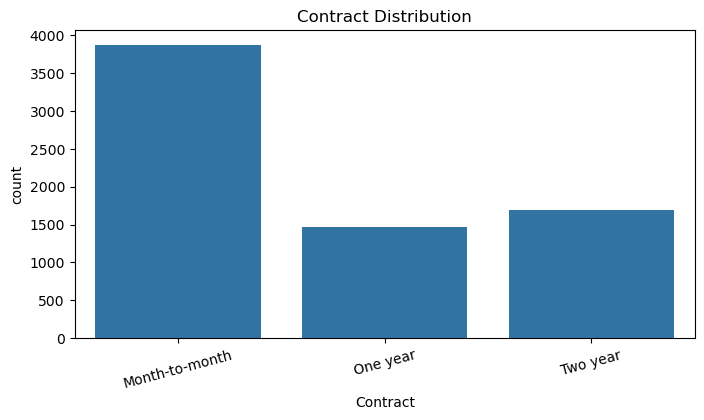

In [16]:
# Contract Distribution

plt.figure(figsize=(8,4))

sns.countplot(
    x="Contract",
     data =df
)

plt.title("Contract Distribution")
plt.xticks(rotation=15)
plt.show()

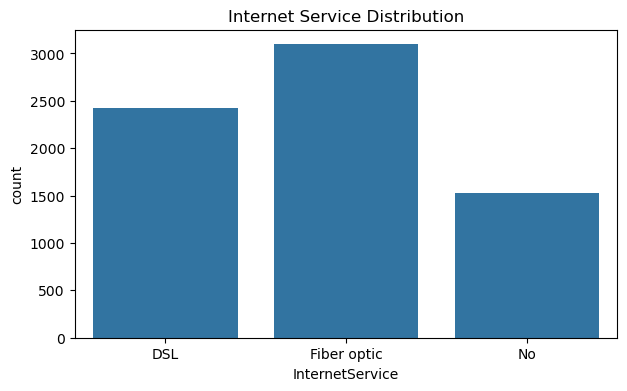

In [17]:
# Internet Service Distribution
plt.figure(figsize=(7,4))

sns.countplot(
    x="InternetService",
    data=df
)

plt.title("Internet Service Distribution")
plt.show()

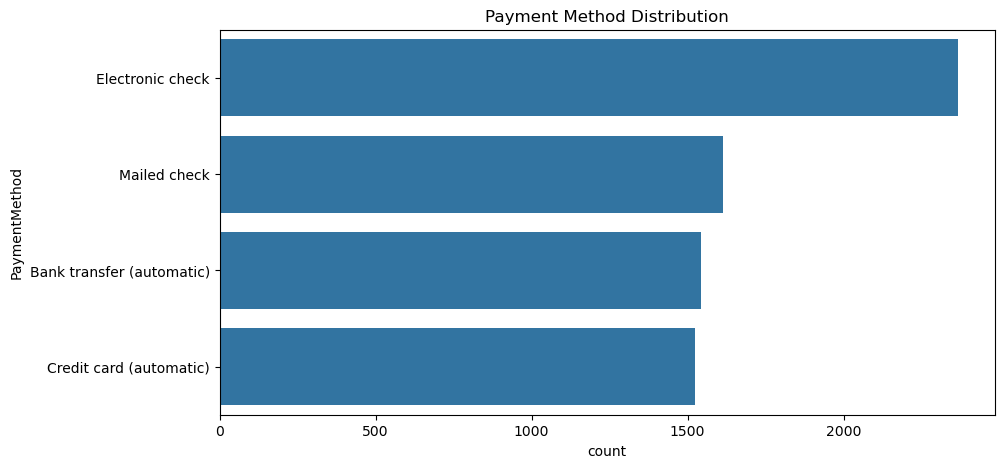

In [18]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="PaymentMethod",
    data=df
)

plt.title("Payment Method Distribution")

plt.show()

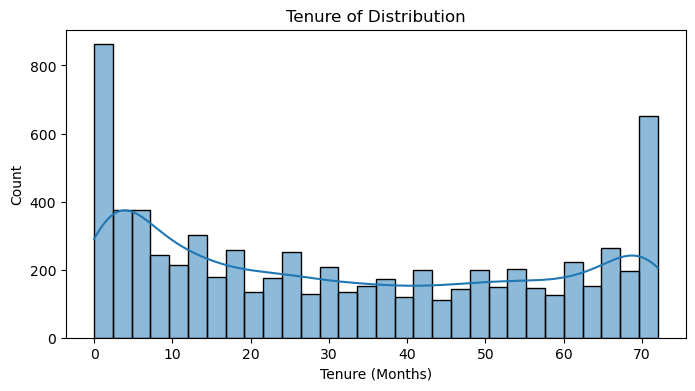

In [19]:
# Tenure Distribution

plt.figure(figsize=(8,4))

sns.histplot(
    df['tenure'],
    bins=30,
    kde=True
)

plt.title("Tenure of Distribution")
plt.xlabel("Tenure (Months)")

plt.show()

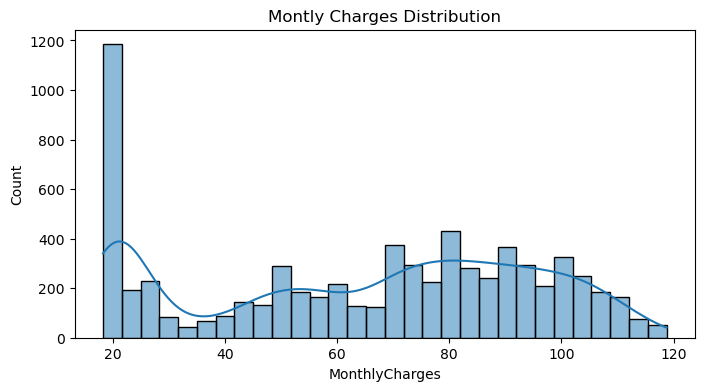

In [20]:
# Monthly Charges Distribution
plt.figure(figsize=(8,4))

sns.histplot(
    df["MonthlyCharges"],
    bins=30,
    kde=True
)

plt.title("Montly Charges Distribution")
plt.show()

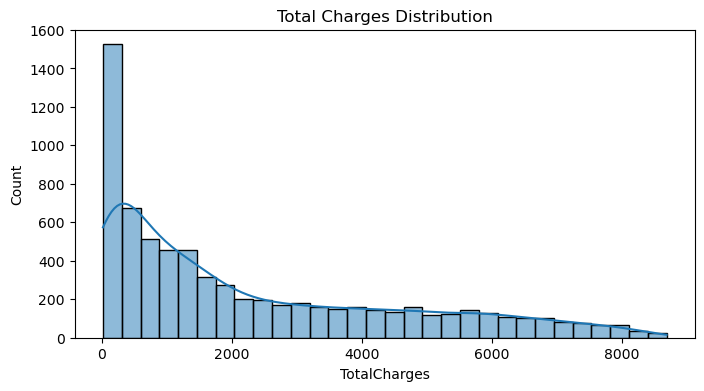

In [21]:
# Total Charges Distribution
plt.figure(figsize=(8,4))

sns.histplot(
    df["TotalCharges"],
    bins=30,
    kde=True
)
plt.title("Total Charges Distribution")
plt.show()

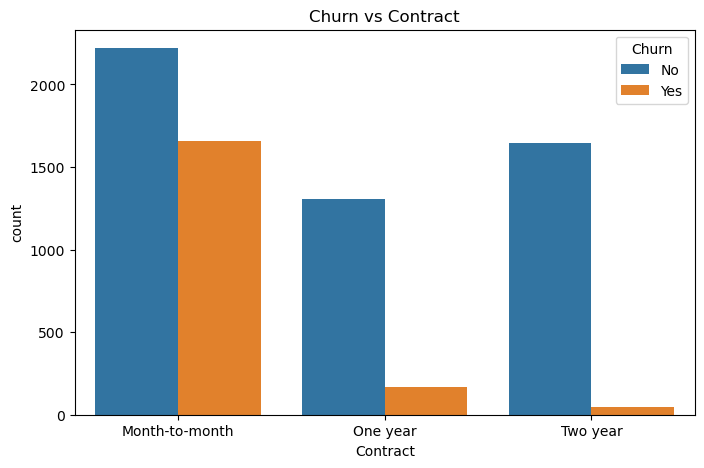

In [22]:
# Churn vs Contract 
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Churn vs Contract")
plt.show()

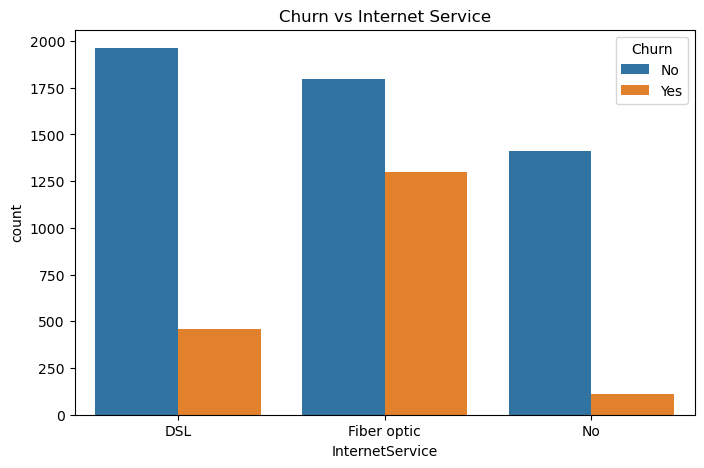

In [23]:
# Churn vs Internet Service
plt.figure(figsize=(8, 5))
sns.countplot( x="InternetService", hue="Churn", data=df )
plt.title("Churn vs Internet Service") 
plt.show()

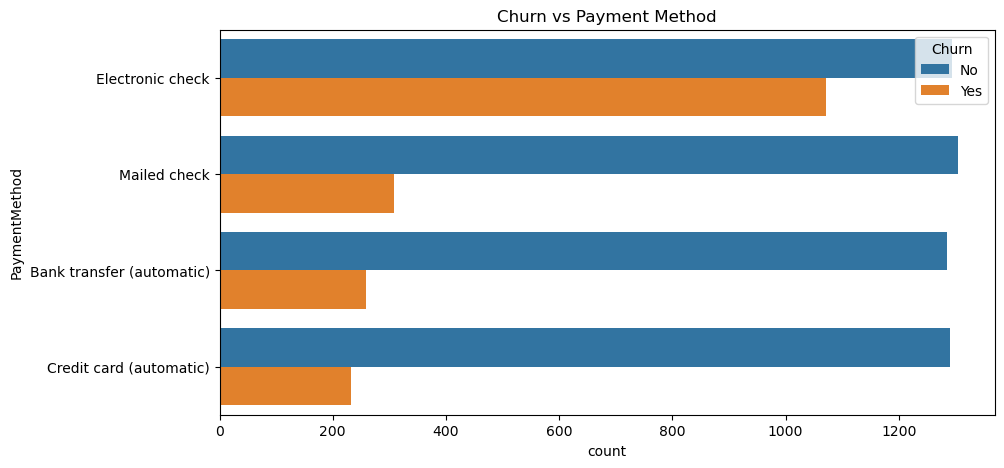

In [24]:
# Churn vs Payment Method
plt.figure(figsize=(10,5))

sns.countplot(
    y="PaymentMethod",
    hue="Churn",
    data=df

)

plt.title("Churn vs Payment Method")
plt.show()

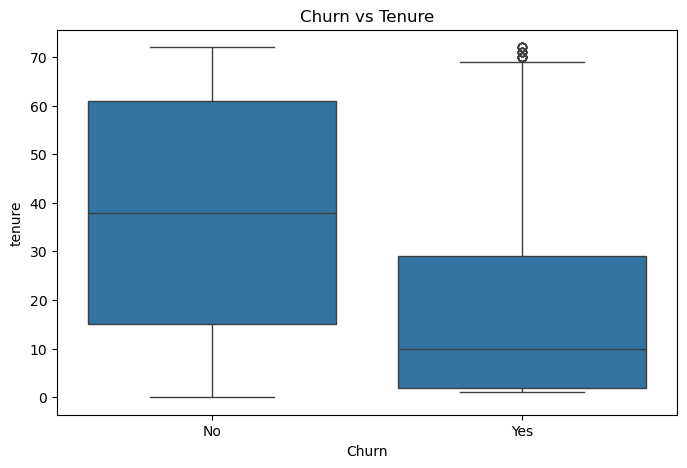

In [25]:
# Churn vc Tenure
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)
plt.title("Churn vs Tenure")
plt.show()

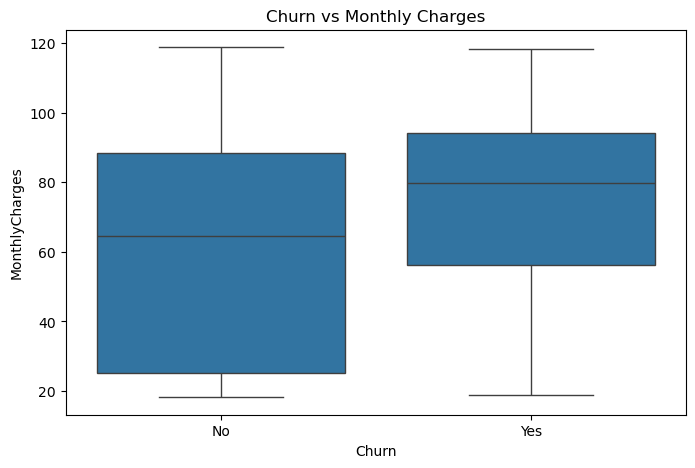

In [26]:
# Churn vs Monthly Charges
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Churn vs Monthly Charges")

plt.show()

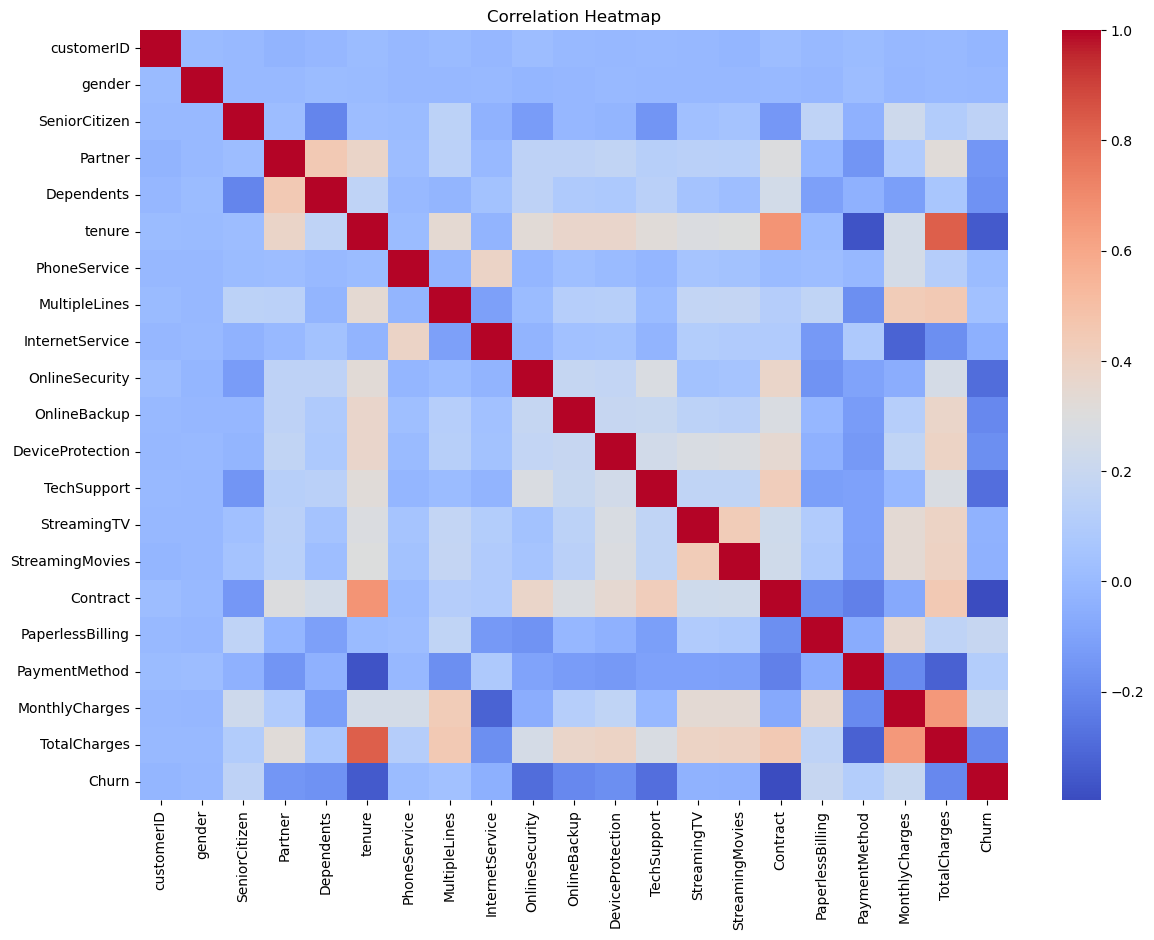

In [27]:
# Correlation Analysis

corr_df=df.copy()

for col in corr_df.select_dtypes(include="object").columns:
    corr_df[col]=corr_df[col].astype("category").cat.codes

# Correlation Matrix

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

**Prepare For Machine Learning**

In [28]:
data=df.copy()

data["Churn"]= data["Churn"].map({
    "No": 0,
    "Yes" : 1
})

# Remove Customer ID:
data = data.drop(
    "customerID",
    axis=1
)


**Separate X and Y**

In [29]:

x=data.drop(
    "Churn",
    axis=1
)
y=data["Churn"]

# Check

print("X shape:",x.shape)
print("Y Shape:",y.shape)



X shape: (7043, 19)
Y Shape: (7043,)


**Identify Numerical and Categorical Columns**

In [30]:
categorical_cols=x.select_dtypes(
    include="object"
).columns.tolist()

numeric_cols=x.select_dtypes(
    exclude="object"
).columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numeric_cols)

Categorical Columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical Columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


**Train-Test Split**

In [31]:
# Train-Test Split

x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.20,
    random_state=42,
    stratify=y
)

# Check the Shape
print("X_train:",x_train.shape)
print("X_test:",x_test.shape)

print("Y_train:",y_train.shape)
print("y_test:",y_test.shape)


X_train: (5634, 19)
X_test: (1409, 19)
Y_train: (5634,)
y_test: (1409,)


**Preprocessing**

In [32]:
categorical_transformer=Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            drop="first",
            handle_unknown="ignore"
        )
    )
])

numerical_transformer=Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

preprocessor=ColumnTransformer([
    (
        "categorical",
        categorical_transformer,
        categorical_cols
    ),
    (
        "numerical",
        numerical_transformer,
        numeric_cols
    )
])


Logistic Regression

In [33]:
lr_pipeline=Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

# Troin

lr_pipeline.fit(
    x_train,
    y_train
)

# Prediction
lr_pred=lr_pipeline.predict(x_test)
print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


Random Forest

In [34]:
rf_pipeline=Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "mode",
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )
    )
])

# train
rf_pipeline.fit(
    x_train,
    y_train)

rf_pred=rf_pipeline.predict(x_test)
print("Random Forest trained successfully!")

Random Forest trained successfully!


XGBoost

In [35]:
xgb_pipeline=Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss"
        )
    )
])

# train
xgb_pipeline.fit(x_train,y_train)

xgb_pred=xgb_pipeline.predict(x_test)
print("XGBoost trained successfully!")

XGBoost trained successfully!


Compare all Three Models

In [36]:
results=pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,xgb_pred)
    ],
    "Precision":[
        precision_score(y_test,lr_pred),
        precision_score(y_test,rf_pred),
        precision_score(y_test,xgb_pred)
    ],
    "Recall":[
        recall_score(y_test,lr_pred),
        recall_score(y_test,rf_pred),
        recall_score(y_test,xgb_pred),
    ],
    "F1 Score":[
        f1_score(y_test,lr_pred),
        f1_score(y_test,rf_pred),
        f1_score(y_test,xgb_pred)
    ],
    "ROC-AUC":[
        roc_auc_score(
            y_test,
            lr_pipeline.predict_proba(x_test)[:,1]
        ),

        roc_auc_score(
            y_test,
            rf_pipeline.predict_proba(x_test)[:,1]
        ),

        roc_auc_score(
            y_test,
            xgb_pipeline.predict_proba(x_test)[:,1]
        )
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804116,0.653125,0.558824,0.602305,0.842561
1,Random Forest,0.794890,0.643098,0.510695,0.569300,0.826282
2,XGBoost,0.797019,0.639241,0.540107,0.585507,0.833176


Comparison Graph

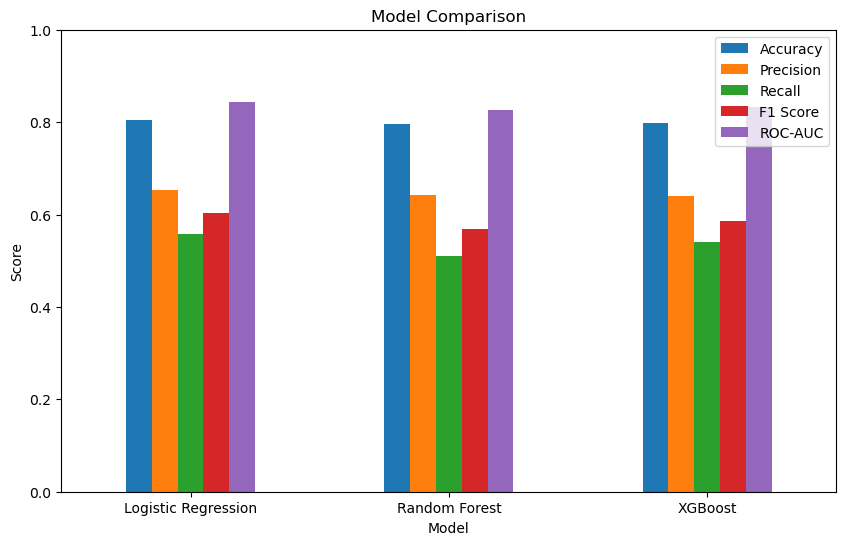

In [37]:
results.set_index("Model")[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1)

plt.show()

XGBoost Classification Report

In [38]:
print(
    classification_report(
        y_test,
        xgb_pred
    )
)


              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



XGBoost Confusion Matrix

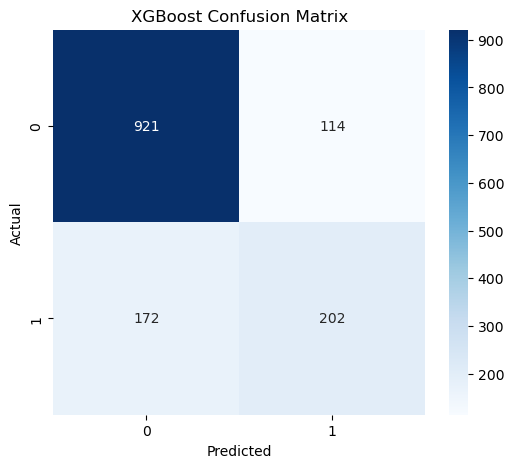

In [39]:
cm=confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

XGBoost Hyperparameter Tuning

In [40]:
params={
    "model__n_estimators":[100,200,300],
    "model__max_depth":[3,5,7],
    "model__learning_rate":[0.01,0.05,0.1],
    "model__subsample":[0.8,1.0],
    "model__colsample_bytree":[0.8,1.0]
}

In [41]:
random_search=RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=params,
    n_iter=15,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_search.fit(
    x_train,
    y_train
)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV F1 Score:")
print(random_search.best_score_)
    

Best Parameters:
{'model__subsample': 1.0, 'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}

Best CV F1 Score:
0.5899812033188058


Get Best XGBoost model

In [42]:
best_model=random_search.best_estimator_

best_pred=best_model.predict(
    x_test
)

Final Evaluation

In [43]:
print("Final XGBoost Performance")
print("--------------------------")

print(
    "Accuracy :",
    accuracy_score(y_test, best_pred)
)

print(
    "Precision:",
    precision_score(y_test, best_pred)
)

print(
    "Recall   :",
    recall_score(y_test, best_pred)
)

print(
    "F1 Score :",
    f1_score(y_test, best_pred)
)

print(
    "ROC-AUC  :",
    roc_auc_score(
        y_test,
        best_model.predict_proba(x_test)[:, 1]
    )
)

Final XGBoost Performance
--------------------------
Accuracy : 0.7991483321504613
Precision: 0.6531986531986532
Recall   : 0.5187165775401069
F1 Score : 0.5782414307004471
ROC-AUC  : 0.8423531995143249


Final Classification Report

In [44]:
print(
    classification_report(
        y_test,
        best_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



Final confusion matrix

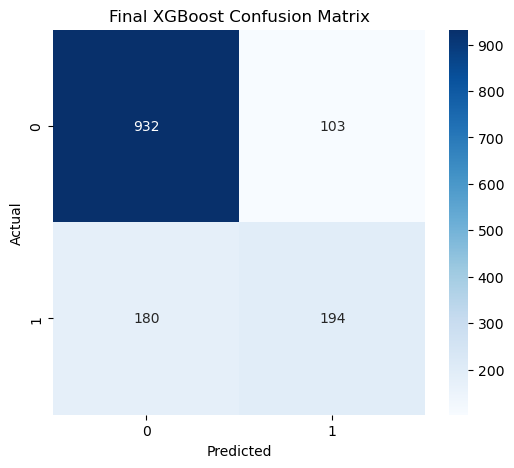

In [45]:
cm = confusion_matrix(
    y_test,
    best_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final XGBoost Confusion Matrix")

plt.show()

 Feature Importance

In [46]:
final_xgb = best_model.named_steps["model"]

final_preprocessor = best_model.named_steps["preprocessor"]

feature_names = final_preprocessor.get_feature_names_out()

importance = pd.Series(
    final_xgb.feature_importances_,
    index=feature_names
).sort_values(
    ascending=False
)

print(importance.head(15))

categorical__InternetService_Fiber optic       0.218688
categorical__Contract_One year                 0.201639
categorical__Contract_Two year                 0.171064
categorical__InternetService_No                0.086742
categorical__PaymentMethod_Electronic check    0.074045
numerical__tenure                              0.043059
categorical__StreamingMovies_Yes               0.026764
categorical__OnlineSecurity_Yes                0.026431
categorical__PaperlessBilling_Yes              0.019953
categorical__TechSupport_Yes                   0.016833
categorical__StreamingTV_Yes                   0.015927
categorical__MultipleLines_Yes                 0.013163
categorical__Dependents_Yes                    0.010340
categorical__gender_Male                       0.009459
numerical__TotalCharges                        0.008976
dtype: float32


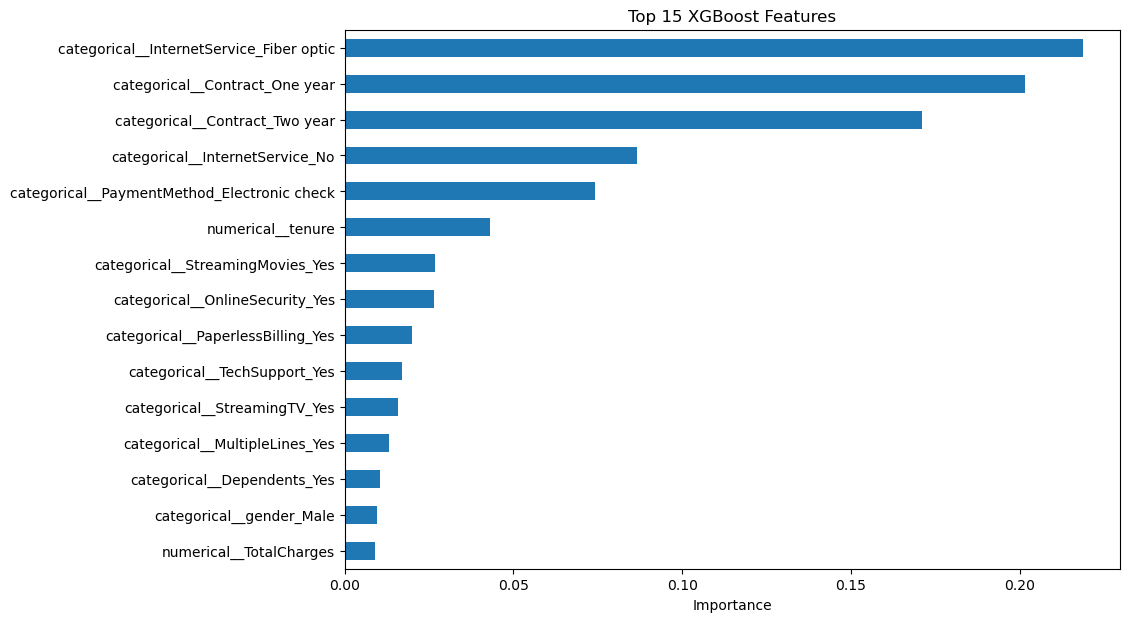

In [47]:
plt.figure(figsize=(10,7))

importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 XGBoost Features")
plt.xlabel("Importance")

plt.show()

Save the Model

In [48]:
joblib.dump(
    best_model,
    "customer_churn_xgboost_pipeline.pkl"
)

print("✅ Model saved successfully!")

✅ Model saved successfully!
